## Project Overview

This notebook performs a classification task to detect tax fraud. It involves loading a dataset, extensive data cleaning and exploratory data analysis (EDA), feature engineering to create new predictive features, and then training and evaluating several machine learning models, including Decision Tree, Random Forest, and XGBoost. Hyperparameter tuning is applied to optimize Random Forest and XGBoost models. Finally, the best performing model is used to make predictions on a test dataset and saved for future use.

In [1]:
# importation of libraries
import  pandas as pd
import  numpy as np
import  matplotlib.pyplot as plt
import  seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


In [2]:
# load the dataset
df=pd.read_csv("Train.csv")
df

,BCT_CODBUR,CTR_MATFIS,CTR_CATEGO_X,FJU_CODFJU,CTR_CESSAT,ACT_CODACT,CTR_OBLDIR,CTR_OBLACP,CTR_OBLRES,CTR_OBLFOP,...,target,FAC_MNTPRI_F,FAC_MFODEC_F,FAC_MNTDCO_F,FAC_MNTTVA_F,FAC_MNTPRI_C,FAC_MFODEC_C,FAC_MNTDCO_C,FAC_MNTTVA_C,id
0,44,6210,C,99,0,3707,4,2,2,2,...,16.639203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id17437
1,401,14383,M,22,0,6105,4,2,2,2,...,17.827703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id5086
2,243,11555,M,23,0,5751,4,2,2,2,...,15.473503,25387000.0,0.0,0.0,4571280.0,NaN,NaN,NaN,NaN,train_id1443
3,72,6175,C,99,0,4402,4,2,2,2,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id15469
4,42,1417,M,23,0,6302,4,2,2,2,...,14.286244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id14368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21290,47,6766,M,22,0,4203,4,2,2,2,...,16.544842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id7173
21291,113,15006,M,21,0,5703,4,2,2,3,...,17.651115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id12850
21292,700,2429,M,22,0,4218,4,2,2,2,...,18.018778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id4062
21293,248,1323,M,22,0,3201,4,2,2,2,...,15.521108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id4052


# DATA CLEANING AND EDA

In [3]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21295 entries, 0 to 21294
Columns: 121 entries, BCT_CODBUR to id
dtypes: float64(103), int64(16), object(2)
memory usage: 19.7+ MB


In [4]:
# statistical summary of the dataset
df.describe()

,BCT_CODBUR,CTR_MATFIS,FJU_CODFJU,CTR_CESSAT,ACT_CODACT,CTR_OBLDIR,CTR_OBLACP,CTR_OBLRES,CTR_OBLFOP,CTR_OBLTFP,...,RES_ANNIMP,target,FAC_MNTPRI_F,FAC_MFODEC_F,FAC_MNTDCO_F,FAC_MNTTVA_F,FAC_MNTPRI_C,FAC_MFODEC_C,FAC_MNTDCO_C,FAC_MNTTVA_C
count,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,...,21295.000000,21295.000000,1.820000e+03,1.820000e+03,1.820000e+03,1.820000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03
mean,214.935807,7797.448697,59.580888,0.048509,4821.595445,4.454191,1.959850,1.977319,1.928105,1.949096,...,2014.508852,11.780084,9.471275e+09,6.632605e+06,9.306873e+04,4.903870e+08,8.420356e+08,1.489097e+06,3.191820e+04,1.386915e+08
std,162.992837,4484.430937,38.542427,0.228200,1168.628546,1.205500,0.196316,0.154462,0.263361,0.221933,...,1.332947,7.085772,1.297572e+11,2.091579e+08,3.596381e+06,4.739676e+09,4.107717e+09,1.733094e+07,7.106121e+05,7.148914e+08
min,9.000000,1.000000,10.000000,0.000000,1002.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2013.000000,0.000000,2.173000e+04,0.000000e+00,0.000000e+00,0.000000e+00,4.910000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,92.000000,3944.000000,22.000000,0.000000,4203.000000,4.000000,2.000000,2.000000,2.000000,2.000000,...,2013.000000,0.000000,3.024577e+07,0.000000e+00,0.000000e+00,4.360140e+06,1.906574e+07,0.000000e+00,0.000000e+00,2.927028e+06
50%,182.000000,7817.000000,23.000000,0.000000,4417.000000,4.000000,2.000000,2.000000,2.000000,2.000000,...,2014.000000,14.981121,1.997162e+08,0.000000e+00,0.000000e+00,2.989651e+07,5.594731e+07,0.000000e+00,0.000000e+00,8.642968e+06
75%,254.000000,11695.500000,99.000000,0.000000,6102.000000,4.000000,2.000000,2.000000,2.000000,2.000000,...,2015.000000,16.625623,9.257110e+08,0.000000e+00,0.000000e+00,1.426512e+08,2.707424e+08,0.000000e+00,0.000000e+00,4.414594e+07
max,700.000000,15603.000000,99.000000,2.000000,8999.000000,9.000000,2.000000,5.000000,5.000000,3.000000,...,2018.000000,23.591334,3.414507e+12,8.897885e+09,1.529912e+08,1.608777e+11,8.351128e+10,4.044067e+08,2.614500e+07,1.352152e+10


In [5]:
# shape of the dataset
df.shape

(21295, 121)

In [6]:
# columns datatypes
df.dtypes

,0
BCT_CODBUR,int64
CTR_MATFIS,int64
CTR_CATEGO_X,object
FJU_CODFJU,int64
CTR_CESSAT,int64
...,...
FAC_MNTPRI_C,float64
FAC_MFODEC_C,float64
FAC_MNTDCO_C,float64
FAC_MNTTVA_C,float64


In [7]:
# duplicate values
df.duplicated().sum()/len(df)*100

np.float64(0.0)

In [8]:
# missing values
df.isnull().sum()/len(df)*100

,0
BCT_CODBUR,0.000000
CTR_MATFIS,0.000000
CTR_CATEGO_X,0.000000
FJU_CODFJU,0.000000
CTR_CESSAT,0.000000
...,...
FAC_MNTPRI_C,90.077483
FAC_MFODEC_C,90.077483
FAC_MNTDCO_C,90.077483
FAC_MNTTVA_C,90.077483


In [9]:
# colums with more than 50% missing values
missing_pct = (df.isnull().sum() / len(df)) * 100

print(missing_pct[missing_pct > 50])


ADB_MNTORD      74.843860
SND_MNTPRD_I    82.629725
SND_MNTTVA_I    82.629725
SND_MNTDRC_I    82.629725
SND_MNTAVA_I    82.629725
SND_MNTTAX_I    82.629725
SND_MNTPAY_I    82.629725
SND_MNTAIR_I    82.629725
SND_MNTPRD_E    94.219300
SND_MNTTVA_E    94.219300
SND_MNTDRC_E    94.219300
SND_MNTAVA_E    94.219300
SND_MNTTAX_E    94.219300
SND_MNTPAY_E    94.219300
SND_MNTAIR_E    94.219300
SND_MNTPRD_A    86.386476
SND_MNTTVA_A    86.386476
SND_MNTDRC_A    86.386476
SND_MNTAVA_A    86.386476
SND_MNTTAX_A    86.386476
SND_MNTPAY_A    86.386476
SND_MNTAIR_A    86.386476
FAC_MNTPRI_F    91.453393
FAC_MFODEC_F    91.453393
FAC_MNTDCO_F    91.453393
FAC_MNTTVA_F    91.453393
FAC_MNTPRI_C    90.077483
FAC_MFODEC_C    90.077483
FAC_MNTDCO_C    90.077483
FAC_MNTTVA_C    90.077483
dtype: float64


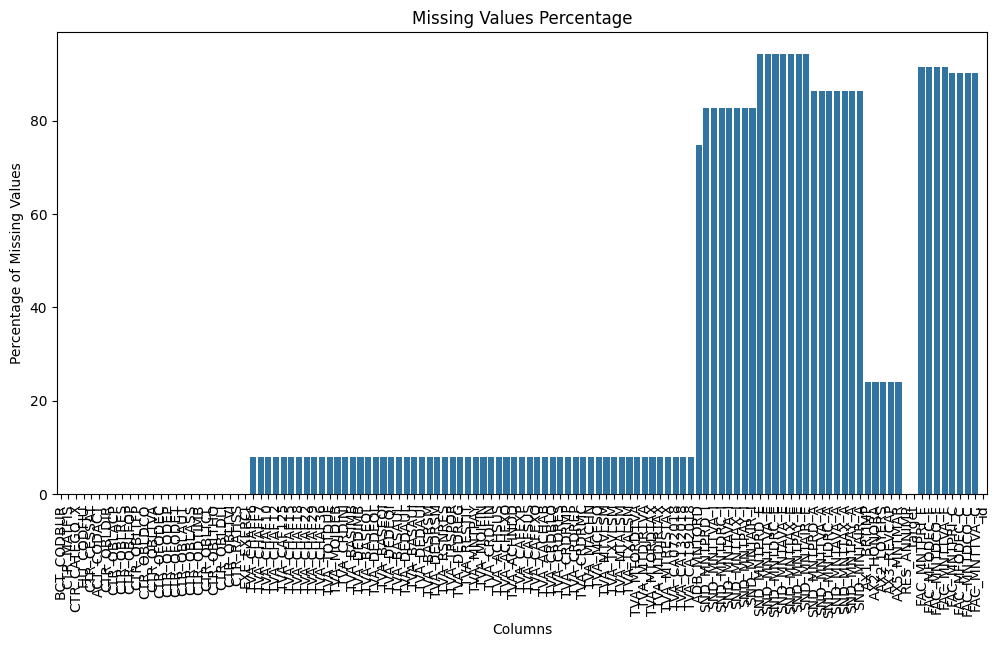

In [10]:
plt.figure(figsize=(12, 6))
plt.title('Missing Values Percentage')
sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values')
plt.xticks(rotation=90)
plt.show()

### Visualization of Missing Values

This cell generates a bar plot visualizing the percentage of missing values for each column. This graphical representation makes it easier to spot columns with significant amounts of missing data and decide on appropriate handling strategies.

In [11]:
df.drop(missing_pct[missing_pct > 50].index, axis=1, inplace=True)

In [12]:
# filling missing values with mean for numerical columns
# filling missing values for categorical columns with  unknown
missing_cols = df.columns[df.isnull().any()]

for col in missing_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mean())

In [13]:
# numerical values and categorical values
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['BCT_CODBUR', 'CTR_MATFIS', 'FJU_CODFJU', 'CTR_CESSAT', 'ACT_CODACT',
       'CTR_OBLDIR', 'CTR_OBLACP', 'CTR_OBLRES', 'CTR_OBLFOP', 'CTR_OBLTFP',
       'CTR_OBLDCO', 'CTR_OBLTVA', 'CTR_OFODEC', 'CTR_OFODEP', 'CTR_OFODET',
       'CTR_OBLAUT', 'CTR_OBLASS', 'CTR_ODTIMB', 'CTR_OBLTCL', 'CTR_OBLTHO',
       'CTR_OBLDLI', 'CTR_OBLTVI', 'CTR_RATISS', 'EXE_EXERCI', 'TVA_CHAFF6',
       'TVA_CHAFF7', 'TVA_CHAF10', 'TVA_CHAF12', 'TVA_CAF125', 'TVA_CHAF15',
       'TVA_CHAF18', 'TVA_CHAF22', 'TVA_CHAF29', 'TVA_CHAF36', 'TVA_TOTDUE',
       'TVA_MOIDEB', 'TVA_CRDINI', 'TVA_BASIMB', 'TVA_DEDIMB', 'TVA_BASEQL',
       'TVA_DEDEQL', 'TVA_BASEQI', 'TVA_DEDEQI', 'TVA_BASAUL', 'TVA_DEDAUL',
       'TVA_BASAUI', 'TVA_DEDAUI', 'TVA_BASRSM', 'TVA_DEDRSM', 'TVA_RSNRES',
       'TVA_TRSPOR', 'TVA_DEDREG', 'TVA_RESTIT', 'TVA_MNTPAY', 'TVA_MOIFIN',
       'TVA_CRDFIN', 'TVA_ACHSUS', 'TVA_ACHEXO', 'TVA_ACHNDD', 'TVA_CAFEXP',
       'TVA_CAFSUS', 'TVA_CAFEXO', 'TVA_AACHAB', 'TVA_CRD

### Separating Numerical and Categorical Columns

This cell identifies and separates the numerical and categorical columns in the DataFrame. This distinction is crucial for applying appropriate preprocessing techniques, such as scaling for numerical features and one-hot encoding for categorical features.

# VISUALIZATION

## numerical distribution

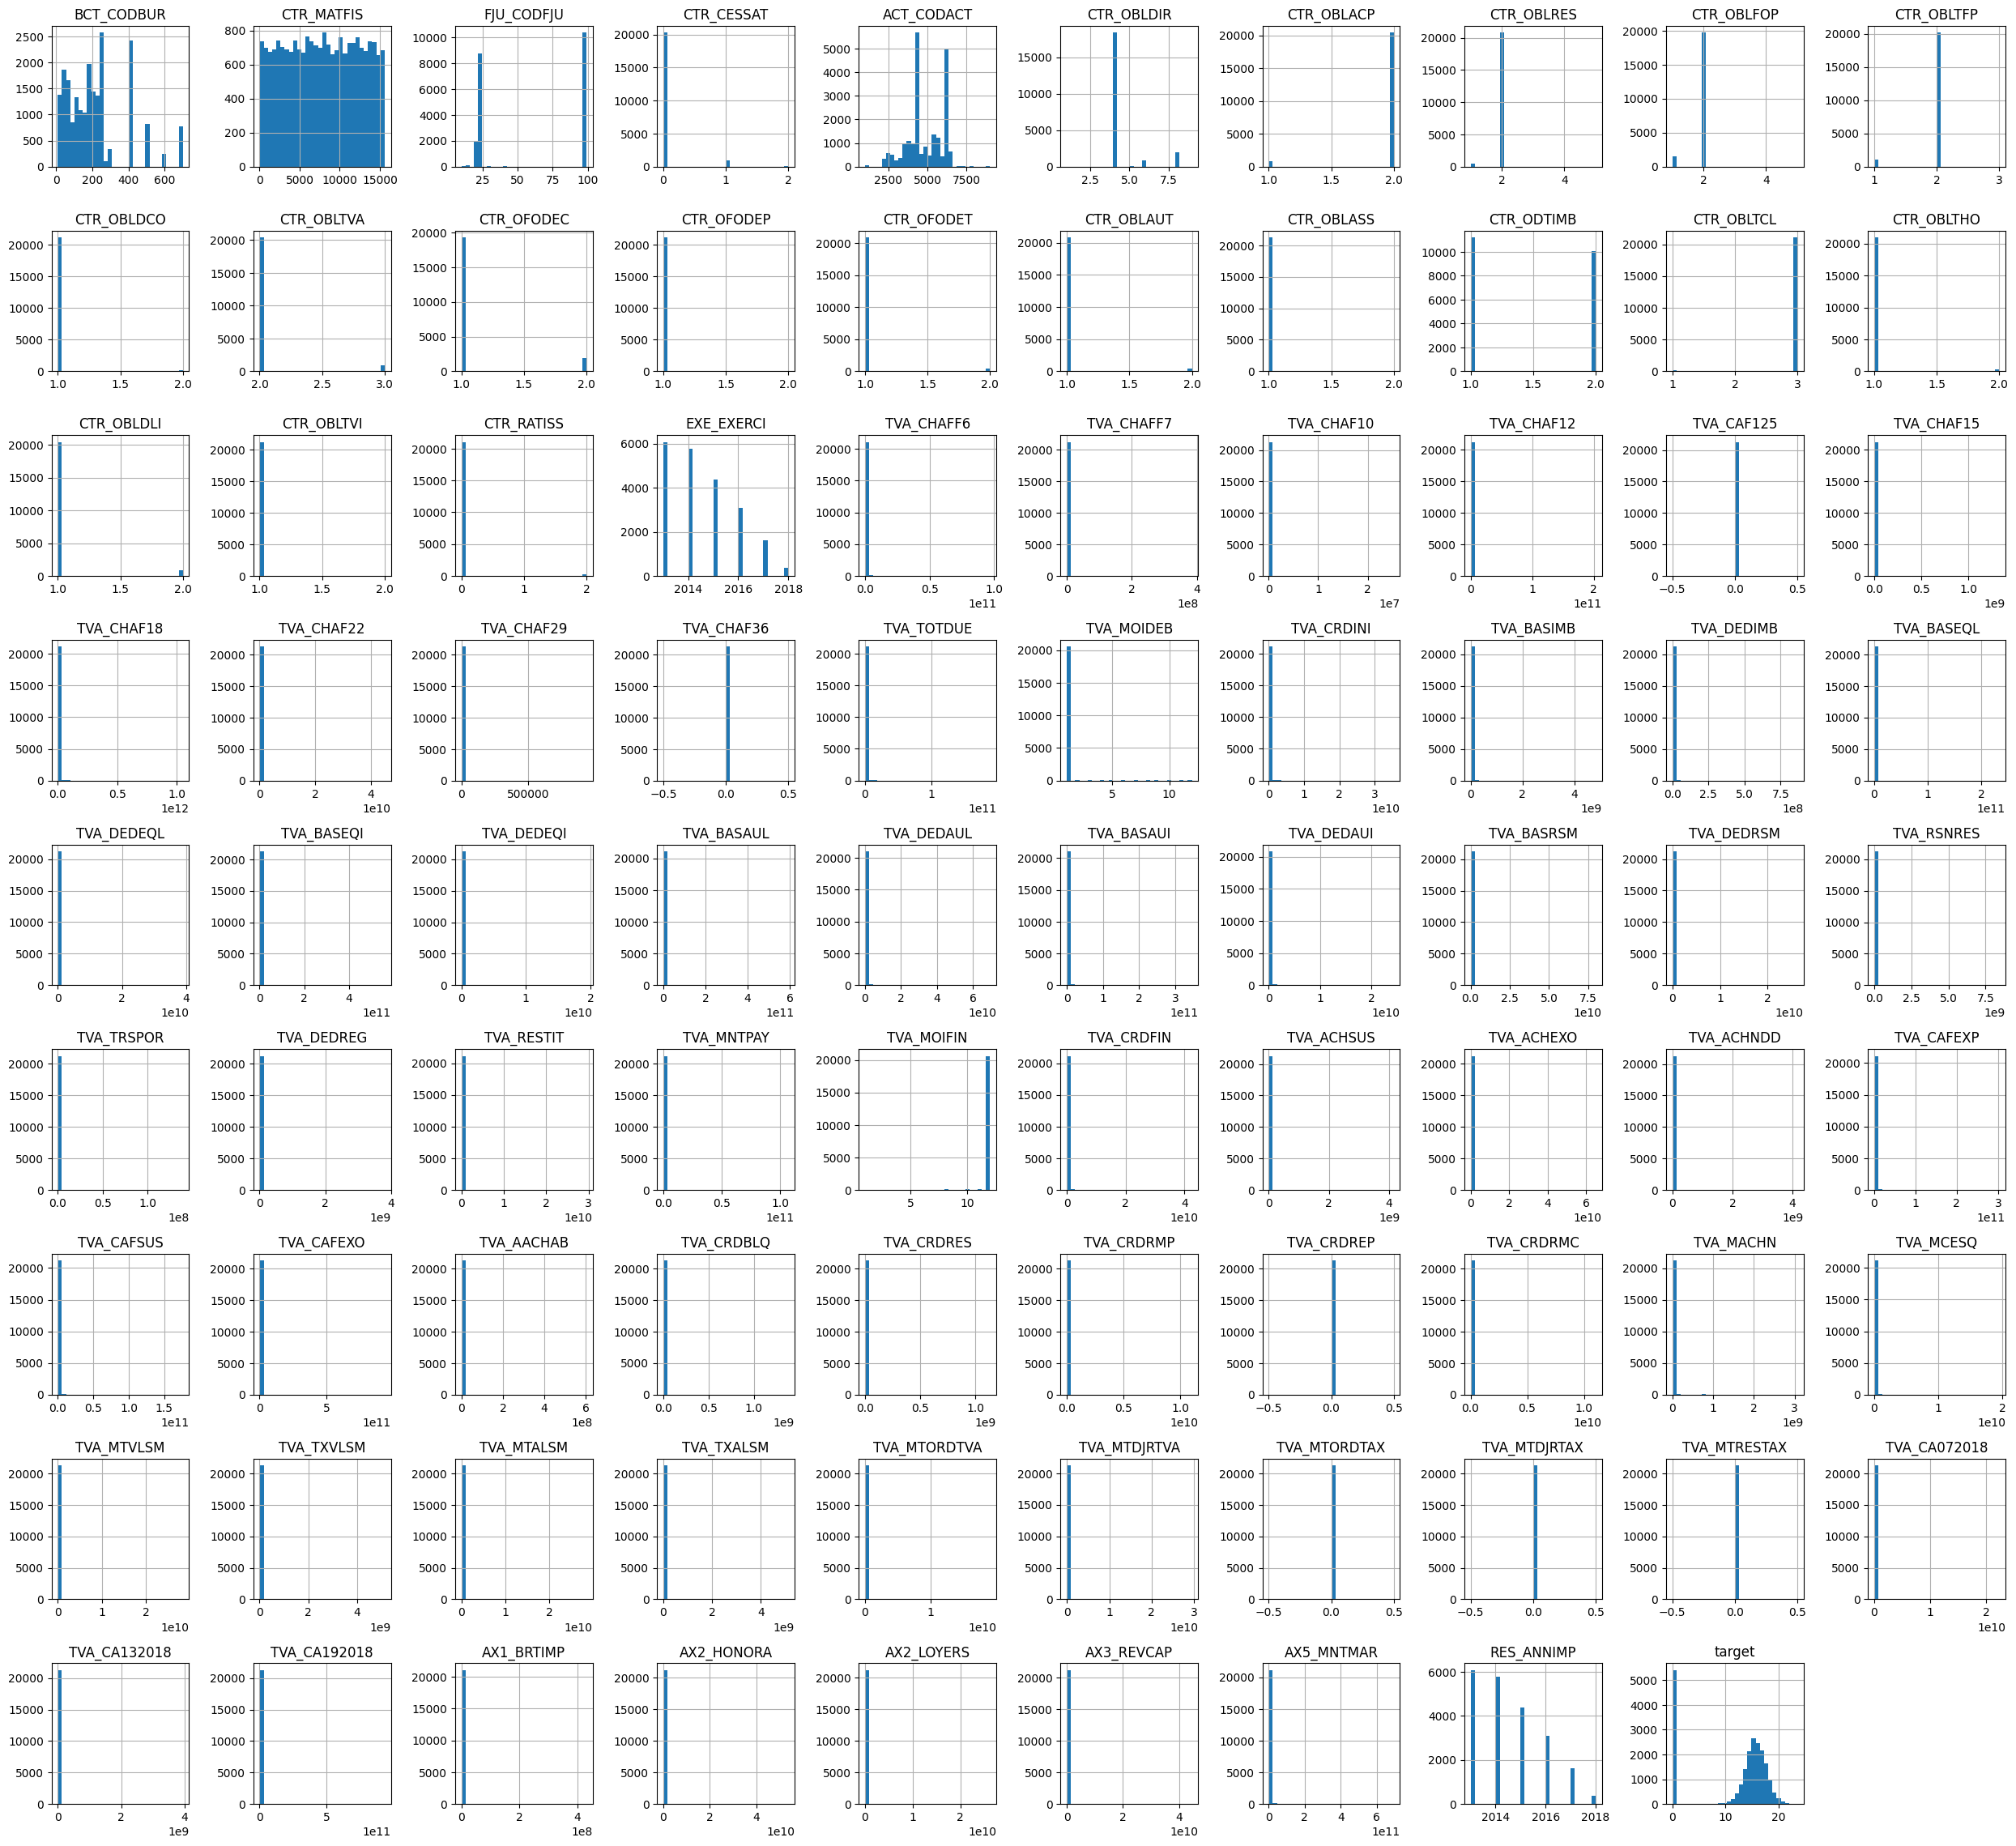

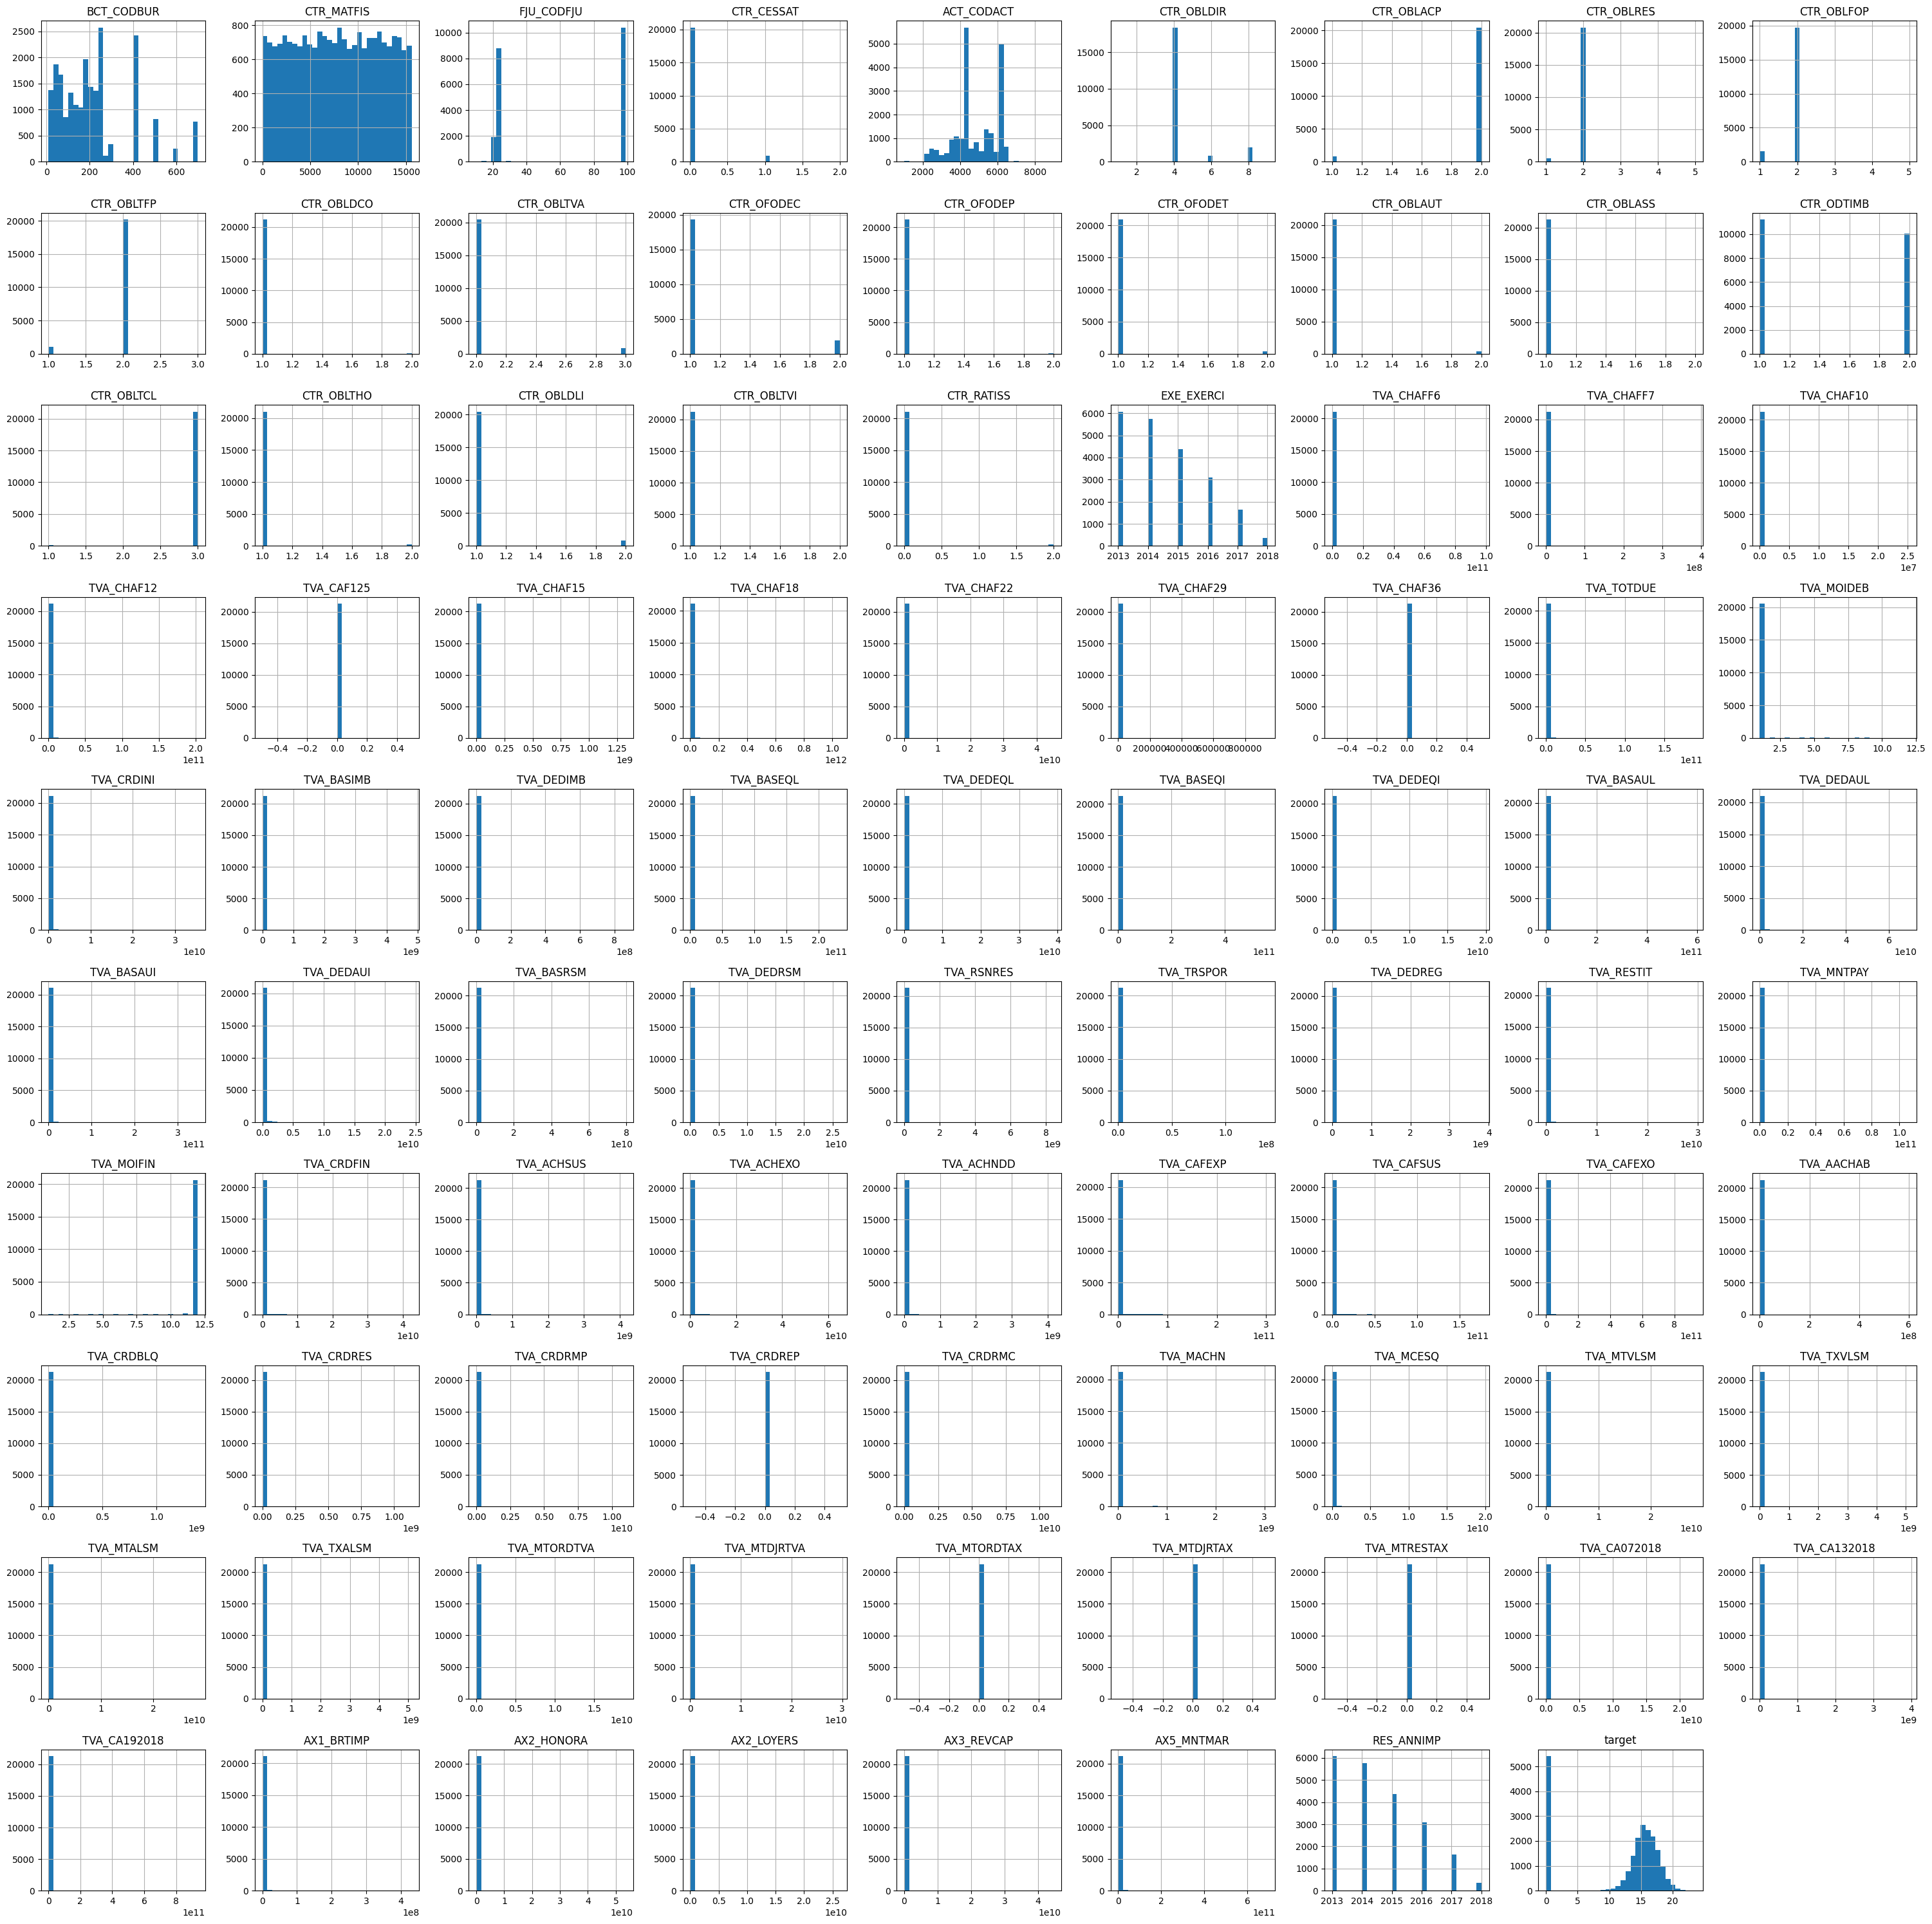

In [14]:
df.hist(
    figsize=(25, 25),
    bins=30,
    layout=(10, 10)  # adjust based on number of columns
)

plt.tight_layout()
plt.show()
df.select_dtypes(include=['int64', 'float64']).hist(
    figsize=(30, 30),
    bins=30
)

plt.tight_layout()
plt.show()

### Numerical Feature Distributions

This cell generates histograms for all numerical columns in the DataFrame. Histograms provide a visual representation of the distribution of each feature, helping to identify skewness, outliers, and the general shape of the data, which can inform further preprocessing or feature transformation steps.

## Target Variable Distribution

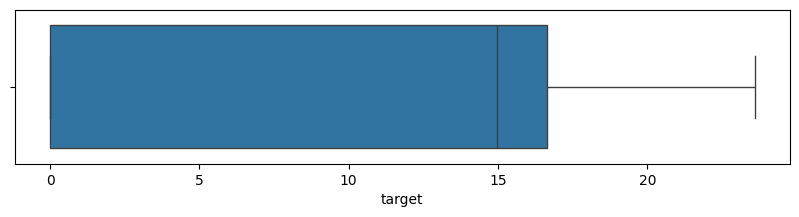

In [15]:
plt.figure(figsize=(10,2))
sns.boxplot(x=df['target'])
plt.show()

### Target Variable Distribution (Box Plot)

This cell displays a box plot of the `target` variable. A box plot is useful for visualizing the distribution of the target variable, identifying its median, quartiles, and potential outliers. This helps in understanding the spread and central tendency of the dependent variable.

## Correlation Heatmap

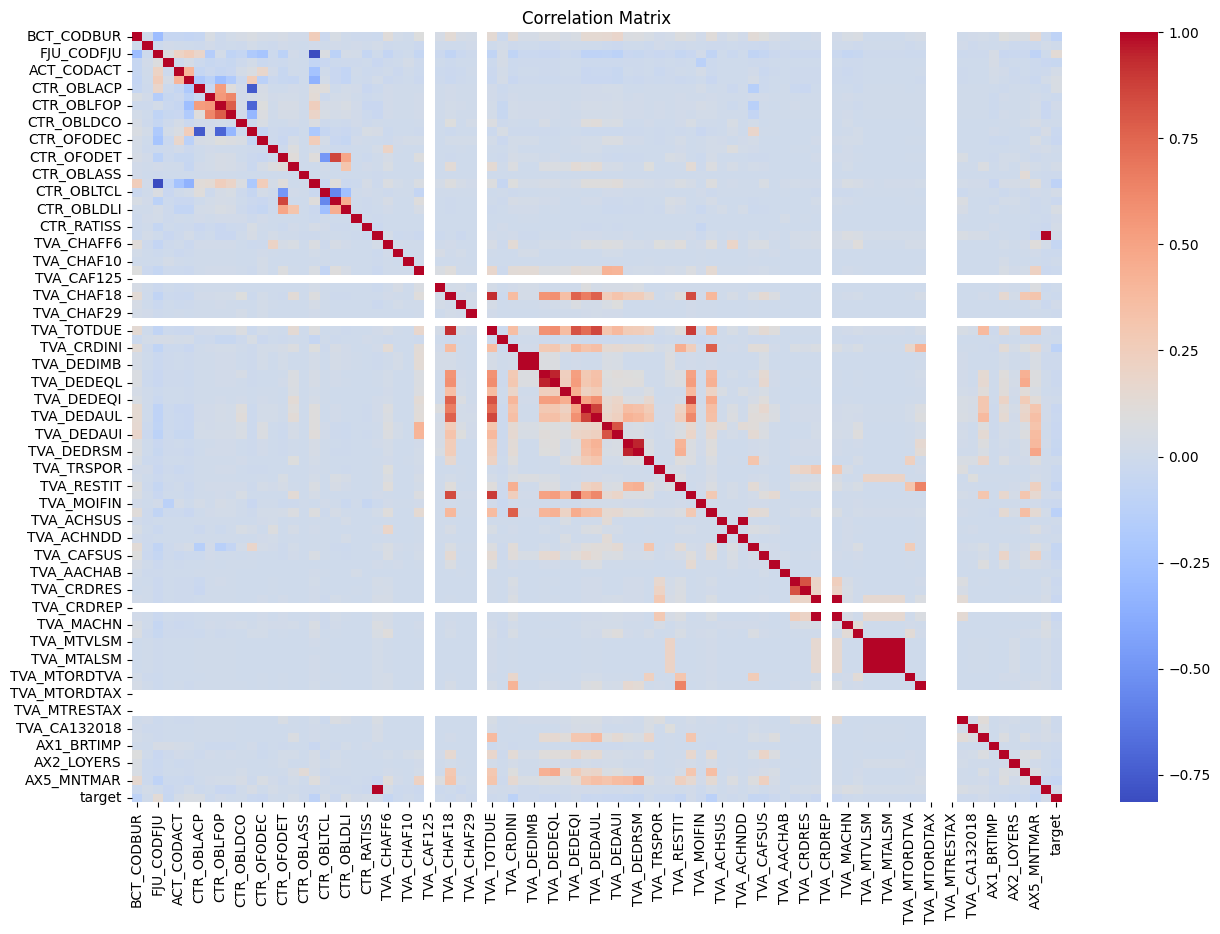

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Correlation Heatmap

This cell computes and visualizes the correlation matrix for all numerical features in the DataFrame using a heatmap. A correlation heatmap helps in identifying relationships between variables, which can be useful for feature selection and understanding multicollinearity.

## outlier detection

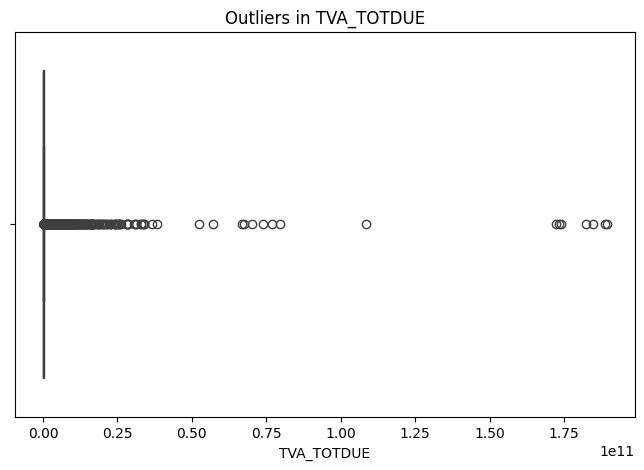

In [17]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['TVA_TOTDUE'])
plt.title('Outliers in TVA_TOTDUE')
plt.show()

### Outlier Detection for 'TVA_TOTDUE'

This cell generates a box plot specifically for the `TVA_TOTDUE` column to detect outliers. Outliers can significantly affect model performance, and visualizing them helps in deciding whether to remove, transform, or impute these extreme values.

# FEATURE ENGENEERING

In [18]:
def engineer_features(df):
    # Tax compliance ratios
    df['TVA_COMPLIANCE_RATIO'] = df['TVA_TOTDUE'] / (df['TVA_CHAFF6'] + 1)
    df['DEDUCTION_RATIO'] = (df['TVA_DEDIMB'] + df['TVA_DEDEQL']) / (df['TVA_CRDINI'] + 1)
    df['SUSPICIOUS_HIGH_DEDUCTION'] = (df['DEDUCTION_RATIO'] > 0.85).astype(int)

    # Activity vs Declaration mismatch
    df['ACTIVITY_DECLARATION_DIFF'] = abs(df['TVA_CHAFF6'] - df['TVA_CHAF10'])

    # Temporal features
    df['HAS_CESSAT'] = (df['CTR_CESSAT'] == 1).astype(int)

    # High-risk flags
    df['HIGH_RISK_CATEGORY'] = df['CTR_CATEGO_X'].isin(['HIGH_RISK_CAT1', 'HIGH_RISK_CAT2']).astype(int)
    return df
df = engineer_features(df)

### Feature Engineering

This cell defines and applies a feature engineering function to create new features that could improve model performance. These new features include tax compliance ratios, activity vs. declaration mismatches, temporal indicators, and high-risk flags, derived from existing columns in the dataset.

## saving cleaned data

In [19]:
# saving for tableau
df.to_csv("tableau_data.csv", index=False)

### Saving Cleaned Data for Tableau

This cell saves the cleaned and feature-engineered DataFrame to a CSV file named `tableau_data.csv`. This is useful for external analysis tools like Tableau, allowing for further interactive data visualization and exploration.

# MODELLING

## spliting data set and scalling


In [25]:
# selecting features and target variable
x = df.drop(['target', 'id'], axis=1)

# Convert the continuous target variable into a binary classification problem
# Assuming values close to zero are one class (e.g., 0) and non-zero values are another (e.g., 1)
y = (df['target'] > 0).astype(int)

### Feature and Target Separation and Binarization

This cell separates the features (`x`) from the target variable (`y`). It also transforms the continuous `target` variable into a binary classification target (0 or 1), where values greater than 0 are classified as 1, and others as 0, suitable for binary classification models.

In [21]:
# Identify feature types from x (after feature engineering)
numeric_features = [col for col in x.columns
                    if x[col].dtype in ['int64', 'float64']
                    and col != 'CTR_CATEGO_X']

categorical_features = [col for col in x.columns
                        if x[col].dtype == 'object']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

### Preprocessing Pipeline Setup

This cell sets up a `ColumnTransformer` for preprocessing. It defines different transformations for numerical and categorical features: `StandardScaler` for numerical features to normalize them, and `OneHotEncoder` for categorical features to convert them into a numerical format suitable for machine learning models. `handle_unknown='ignore'` prevents errors if new categories appear in test data.

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Data Splitting

This cell splits the dataset into training and testing sets using `train_test_split`. `x_train` and `y_train` are used to train the models, while `x_test` and `y_test` are reserved for evaluating the models' performance on unseen data. A `random_state` is set for reproducibility.

## Decison tree

In [33]:
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', DecisionTreeClassifier(random_state=42))])

dt_pipeline.fit(x_train, y_train)

y_pred_dt = dt_pipeline.predict(x_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.54      0.54      1113
           1       0.84      0.84      0.84      3146

    accuracy                           0.76      4259
   macro avg       0.69      0.69      0.69      4259
weighted avg       0.76      0.76      0.76      4259

Decision Tree Confusion Matrix:
[[ 605  508]
 [ 510 2636]]


### Decision Tree Model Training and Evaluation

This cell constructs a machine learning pipeline that first preprocesses the data using the defined `preprocessor` and then applies a `DecisionTreeClassifier`. The pipeline is trained on the training data, and then predictions are made on the test set. Finally, a classification report and confusion matrix are printed to evaluate the model's performance.

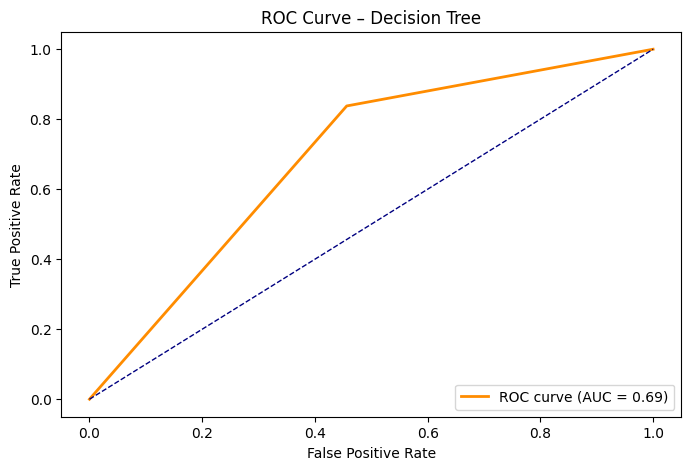

In [ ]:
# ROC Curve for decison tree

from sklearn.metrics import roc_curve, auc

y_prob_dt = dt_pipeline.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Decision Tree')
plt.legend(loc='lower right')
plt.show()

### ROC Curve for Decision Tree

This cell generates and plots the Receiver Operating Characteristic (ROC) curve for the Decision Tree model. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) value provides a single metric to summarize the model's performance across all possible classification thresholds.

#  random forest

In [27]:
from sklearn.pipeline import Pipeline

# Create a pipeline that first preprocesses the data and then trains the RandomForestClassifier
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

# Fit the pipeline to the training data
rf_pipeline.fit(x_train, y_train)

# Make predictions using the fitted pipeline
y_pred_rf = rf_pipeline.predict(x_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.51      0.60      1113
           1       0.84      0.94      0.89      3146

    accuracy                           0.82      4259
   macro avg       0.79      0.72      0.75      4259
weighted avg       0.82      0.82      0.81      4259

Random Forest Confusion Matrix:
[[ 569  544]
 [ 202 2944]]
Random Forest Accuracy: 0.8248415120920404


### Random Forest Model Training and Evaluation

This cell trains a `RandomForestClassifier` using a pipeline that includes the preprocessing steps. After fitting the model to the training data, predictions are made on the test set. A classification report, confusion matrix, and accuracy score are then displayed to assess the Random Forest model's performance.

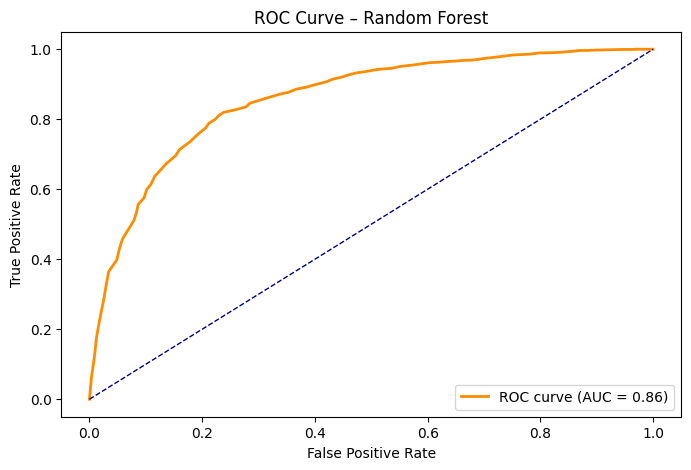

In [28]:
# ROC Curve for Random Forest
from sklearn.metrics import roc_curve, auc

y_prob_rf = rf_pipeline.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.show()

### ROC Curve for Random Forest

This cell generates and plots the ROC curve for the Random Forest model, similar to the Decision Tree. It helps in visualizing and quantifying the model's ability to distinguish between the two classes, with AUC providing a comprehensive performance metric.

## Xgboost

In [36]:
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', XGBClassifier(random_state=42))])

xgb_pipeline.fit(x_train, y_train)

# Make predictions using the fitted pipeline
y_pred_xgb = xgb_pipeline.predict(x_test)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.51      0.59      1113
           1       0.84      0.92      0.88      3146

    accuracy                           0.82      4259
   macro avg       0.77      0.72      0.74      4259
weighted avg       0.81      0.82      0.81      4259

XGBoost Confusion Matrix:
[[ 571  542]
 [ 238 2908]]
XGBoost Accuracy: 0.8168584174688894


### XGBoost Model Training and Evaluation

This cell trains an `XGBClassifier` within a pipeline. The pipeline first preprocesses the data and then fits the XGBoost model. Predictions are generated on the test set, and its performance is evaluated using a classification report, confusion matrix, and accuracy score.

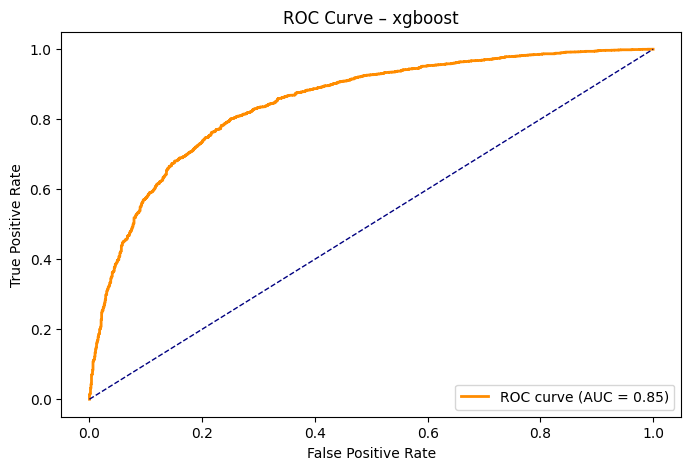

In [38]:
# ROC Curve for Random Forest
from sklearn.metrics import roc_curve, auc

y_prob_xgb = xgb_pipeline.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – xgboost')
plt.legend(loc='lower right')
plt.show()

### ROC Curve for XGBoost

This cell generates and plots the ROC curve for the XGBoost model, providing a visual and quantitative assessment (AUC) of its classification performance. This allows for comparison with other models using a standardized metric.

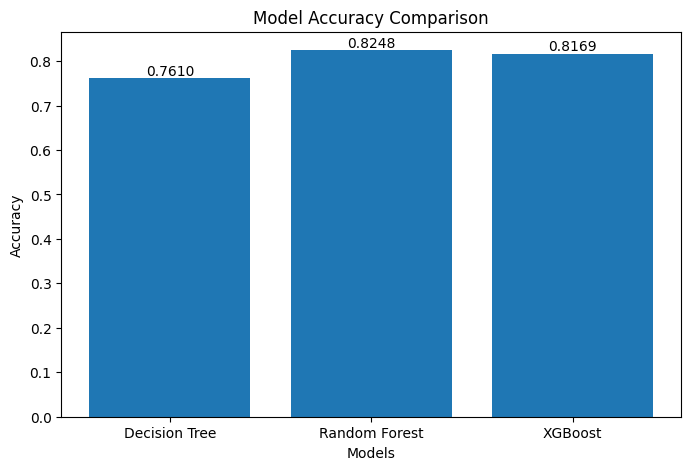

In [41]:
# diffent model evaluations
model_names = ['Decision Tree', 'Random Forest', 'XGBoost']
model_accuracies = [accuracy_score(y_test, y_pred_dt),
                    accuracy_score(y_test, y_pred_rf),
                    accuracy_score(y_test, y_pred_xgb)]


plt.figure(figsize=(8,5))
bars = plt.bar(model_names, model_accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.show()


### Model Accuracy Comparison

This cell calculates and visualizes the accuracy scores of the Decision Tree, Random Forest, and XGBoost models using a bar plot. This comparison helps in quickly identifying which model performed best in terms of overall accuracy on the test set.

## ROC Curve Comparison

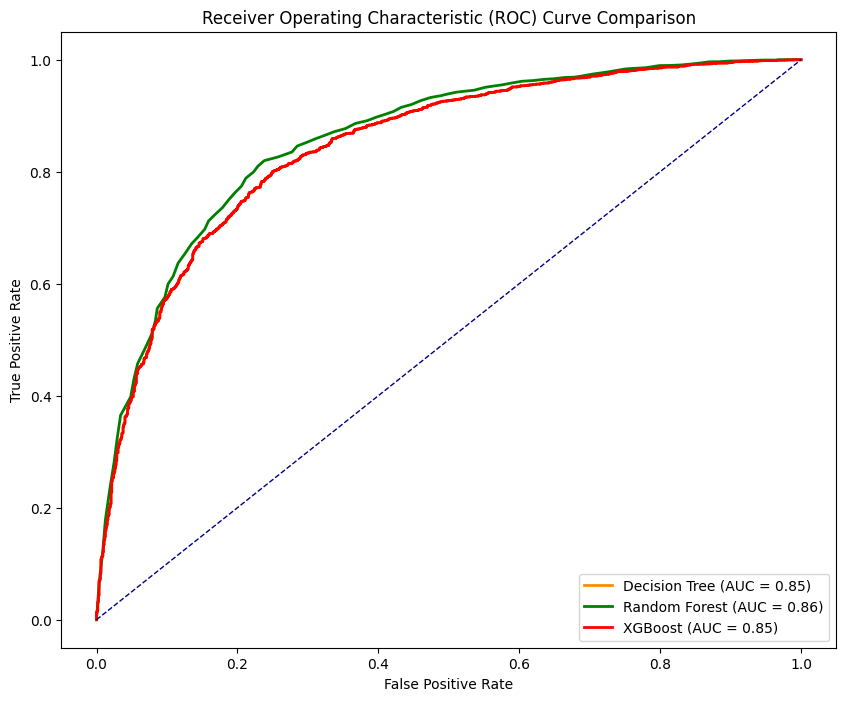

In [42]:
plt.figure(figsize=(10, 8))

# Decision Tree ROC Curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Decision Tree (AUC = {roc_auc:.2f})')

# Random Forest ROC Curve
y_prob_rf = rf_pipeline.predict_proba(x_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# XGBoost ROC Curve
y_prob_xgb = xgb_pipeline.predict_proba(x_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.show()

### ROC Curve Comparison

This cell plots the ROC curves for all three models (Decision Tree, Random Forest, and XGBoost) on a single graph. This combined visualization allows for a direct comparison of their performance across different thresholds and their respective AUC scores, providing insights into their trade-offs between true positive and false positive rates.

# RAMDOM FOREST TUNNING

In [46]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# Apply the preprocessor to x_train to get transformed data
x_train_processed = preprocessor.fit_transform(x_train)

rf_search.fit(x_train_processed, y_train)

print("Best RF Parameters:")
print(rf_search.best_params_)

best_rf = rf_search.best_estimator_

Best RF Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


### Random Forest Hyperparameter Tuning

This cell performs hyperparameter tuning for the Random Forest model using `RandomizedSearchCV`. It searches a defined parameter space (`rf_params`) to find the best combination of hyperparameters that maximizes the R² score, improving the model's predictive capability. The preprocessed training data (`x_train_processed`) is used for fitting.

# XGBOOST TUNNING

In [48]:
from xgboost import XGBClassifier # Import XGBClassifier

xgb = XGBClassifier( # Changed to XGBClassifier
    objective='binary:logistic', # Changed objective for binary classification
    random_state=42
)

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='accuracy', # Changed scoring for classification
    n_jobs=-1,
    random_state=42
)

# Reuse x_train_processed from the previous cell
xgb_search.fit(x_train_processed, y_train)

print("Best XGB Parameters:")
print(xgb_search.best_params_)

best_xgb = xgb_search.best_estimator_

Best XGB Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


### XGBoost Hyperparameter Tuning

This cell performs hyperparameter tuning for the XGBoost classifier using `RandomizedSearchCV`. It defines a parameter grid (`xgb_params`) and searches for the best hyperparameters that optimize the model's accuracy. The preprocessed training data (`x_train_processed`) is used, and the best estimator is stored as `best_xgb`.

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import pandas as pd

results = []

# Transform x_test using the preprocessor
x_test_processed = preprocessor.transform(x_test)

for name, model in [
    ("Random Forest", best_rf),
    ("XGBoost", best_xgb)
]:

    # Use the preprocessed x_test
    preds = model.predict(x_test_processed)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(
        y_test,
        preds
    ) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

print(results_df)

           Model       MAE      RMSE        R2
0  Random Forest  0.173985  0.417114  0.098695
1        XGBoost  0.169993  0.412302  0.119372


### Tuned Model Evaluation Metrics

This cell evaluates the performance of the tuned Random Forest and XGBoost models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score on the processed test data. The results are stored and printed in a DataFrame for clear comparison of the models' predictive accuracy.

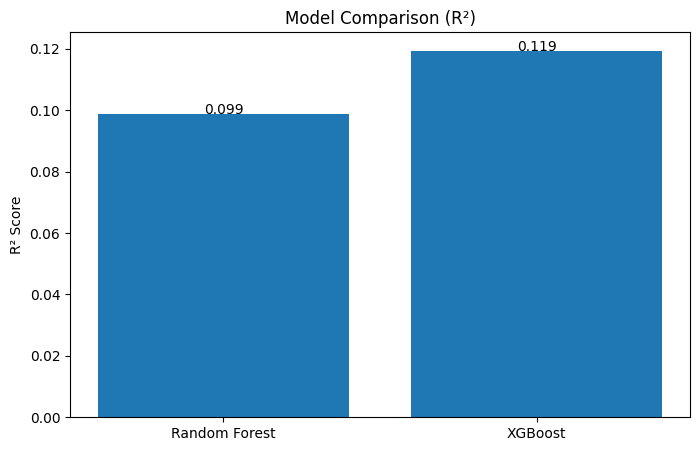

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['R2']
)

plt.title('Model Comparison (R²)')
plt.ylabel('R² Score')

for i, v in enumerate(results_df['R2']):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.show()

### Tuned Model R² Comparison

This cell visualizes the R² scores of the tuned Random Forest and XGBoost models using a bar chart. This graphical comparison provides an easy way to understand which tuned model explains more variance in the target variable.

In [53]:
import pandas as pd

importance = pd.Series(
    best_xgb.feature_importances_,
    index=preprocessor.get_feature_names_out()
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(20))

num__TVA_CRDFIN                   0.068260
num__TVA_RESTIT                   0.053052
num__TVA_MNTPAY                   0.042779
cat__CTR_CATEGO_X_M               0.031938
num__HAS_CESSAT                   0.021905
num__CTR_CESSAT                   0.020532
num__CTR_OBLACP                   0.019716
num__CTR_OBLDLI                   0.018732
num__CTR_OBLTVA                   0.018045
num__CTR_OBLFOP                   0.016428
num__TVA_CRDINI                   0.016211
num__FJU_CODFJU                   0.015606
num__TVA_DEDREG                   0.014858
num__CTR_OBLDIR                   0.013925
num__BCT_CODBUR                   0.013234
num__TVA_CHAFF7                   0.013076
cat__CTR_CATEGO_X_C               0.013012
num__ACTIVITY_DECLARATION_DIFF    0.012975
num__AX3_REVCAP                   0.012832
num__CTR_OBLTFP                   0.012800
dtype: float32


### XGBoost Feature Importance

This cell extracts and displays the top 20 most important features from the best XGBoost model. Feature importance indicates the relative contribution of each feature to the model's predictions, providing insights into which variables are most influential in detecting tax fraud.

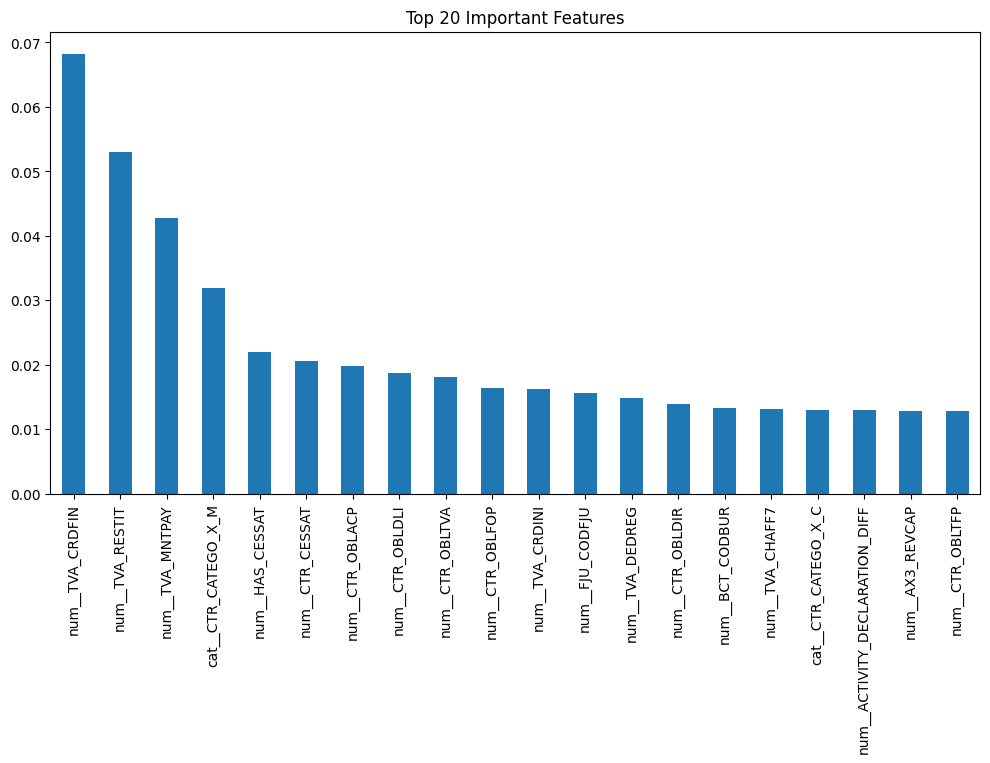

In [54]:
importance.head(20).plot(
    kind='bar',
    figsize=(12,6),
    title='Top 20 Important Features'
)

plt.show()

### Visualization of Top 20 Important Features

This cell generates a bar plot of the top 20 most important features identified by the XGBoost model. This visualization clearly highlights the key factors that contribute most significantly to the model's decision-making process.

In [60]:
import pandas as pd # Ensure pandas is imported

# 1. Load the test dataset from 'Test.csv'
test_data = pd.read_csv("Test.csv")

# 2. Apply feature engineering to the test data
# The 'engineer_features' function was defined earlier in the notebook
x_submission = engineer_features(test_data.copy()) # Use a copy to avoid modifying test_data before dropping 'id'

# 3. Drop the 'id' column as it's not a feature for the model, but keep it in test_data for submission
x_submission = x_submission.drop('id', axis=1)

# 4. Preprocess the submission features using the *already fitted* preprocessor
# 'preprocessor' was fitted on x_train
x_submission_processed = preprocessor.transform(x_submission)

# 5. Make predictions using the best XGBoost model
# Note: If you want to use best_rf predictions, change 'best_xgb' to 'best_rf' here.
predictions = best_xgb.predict(x_submission_processed)


### Generate Predictions for Submission

This cell prepares the test data for final submission. It loads `Test.csv`, applies the same feature engineering steps as the training data, and then preprocesses it using the *already fitted* preprocessor. Finally, it uses the `best_xgb` model to generate predictions for the target variable on this processed test data.

In [62]:
submission = pd.DataFrame({
    'client_id': test_data['id'],
    'target': predictions
})

submission.head()

,client_id,target
0,test_id1120,1
1,test_id1680,1
2,test_id1063,1
3,test_id3731,1
4,test_id9766,1


### Create Submission File

This cell creates a pandas DataFrame for the submission file, mapping the `id` from the original test data to the generated `predictions`. The first few rows of the submission DataFrame are displayed to verify its structure and content.

In [63]:
submission.to_csv('submission.csv', index=False)

### Save Submission File

This cell saves the created `submission` DataFrame to a CSV file named `submission.csv`. The `index=False` argument prevents pandas from writing the DataFrame index as a column in the CSV, which is typically required for submission formats.

In [64]:
import joblib

joblib.dump(best_xgb, 'tax_fraud_detection_model.pkl')
print("\nModel saved as 'tax_fraud_detection_model.pkl'")
# Conclusion: The best XGBoost model has been saved as a pickle file.


Model saved as 'tax_fraud_detection_model.pkl'


### Conclusion: Model Saving

This cell represents the final step of the modeling process, where the `best_xgb` model is saved to a file named `tax_fraud_detection_model.pkl` using `joblib`. This allows the trained model to be easily reloaded and used for future predictions without retraining, making it ready for deployment.